# 🌿 Ecosystem Health, Biodiversity & Blue Carbon
## Arab 813 Hackathon — Planet Tanager Hyperspectral Explorer

This notebook explores **Planet's Tanager hyperspectral satellite** for mapping **ecosystem health, biodiversity proxies, and blue carbon habitats** such as mangroves, seagrass beds, and coastal wetlands.

---

## What You Will Learn

- How hyperspectral data reveals biodiversity-related spectral traits
- How to compute indices linked to ecosystem function
- How to detect blue carbon habitats (mangroves, seagrass)
- How to identify potential harmful algal blooms (HABs)

---

## Why Blue Carbon?

**Blue carbon** refers to carbon stored in coastal ecosystems — mangroves, seagrass meadows, and salt marshes. These ecosystems:
- Store up to **5× more carbon per hectare** than tropical forests
- Protect coastlines from storm surge
- Provide nursery habitat for fish

Tanager's hyperspectral capability allows us to:
- Distinguish mangroves from other coastal vegetation using their unique spectral signature
- Detect chlorophyll in shallow water (seagrass, phytoplankton)
- Monitor ecosystem stress before visible degradation

---

## Relevant STAC Collection

```
https://www.planet.com/data/stac/tanager-core-imagery/coastal-water-bodies/collection.json
```


In [1]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

## Step 1 – Load Items from the Coastal Water Bodies Collection

We target scenes near the UAE and Arabian Gulf — one of the most ecologically important mangrove coasts in the Arabian Peninsula.


In [38]:
import requests

COLLECTION = "coastal-water-bodies"
item_ids = ["20250223_165546_32_4001","20250511_074311_00_4001", "20250223_165546_32_4001", "20250406_170447_47_4001"]

base = f"https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}"
items = []
for iid in item_ids:
    url = f"{base}/{iid}/{iid}.json"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    items.append(r.json())
print(f"Loaded {len(items)} items from {COLLECTION}")

item = items[0]   # work with the first scene

Loaded 4 items from coastal-water-bodies


## Step 2 – Inspect Scene Metadata


In [39]:
from IPython.display import Image
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])
Image(url=item["assets"]["thumbnail"]["href"])

Scene ID: 20250223_165546_32_4001
Date    : 2025-02-23T16:55:46.321891Z
Bbox    : [-88.56425877863482, 13.139414553891845, -88.34746243694369, 13.316052417927148]


In [40]:
import json
print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 0,
  "collection_mode": "standard_sensitivity",
  "constellation": "Tanager",
  "datetime": "2025-02-23T16:55:46.321891Z",
  "description": "All data products from Tanager-1 for 20250223_165546_32_4001 near Usulut\u00e1n, 3401, El Salvador",
  "gsd": 32.85,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 0,
  "location_description": "Usulut\u00e1n, 3401, El Salvador",
  "notes": null,
  "platform": "Planet",
  "plume_provider_ids": null,
  "quality_category": "standard",
  "title": "TanagerScene 20250223_165546_32_4001 Core Imagery",
  "view:azimuth": 263.4,
  "view:off_nadir": 11.2,
  "view:sun_azimuth": 141.3,
  "view:sun_elevation": 61.2
}


## Step 3 – Interactive Map


In [41]:
import leafmap, geopandas as gpd
from shapely.geometry import box

m = leafmap.Map(zoom=8)
ib = item["bbox"]
m.fit_bounds([[ib[1], ib[0]], [ib[3], ib[2]]])

# Scene footprint
gdf = gpd.GeoDataFrame({"geometry": [box(*ib)]}, crs="EPSG:4326")
m.add_gdf(gdf, layer_name="Scene footprint", style={"color":"yellow","fillOpacity":0})

# Visual COG overlay
for vk in ["ortho_visual", "visual", "rendered_preview"]:
    if vk in item.get("assets", {}):
        m.add_cog_layer(item["assets"][vk]["href"],
                        name=item["id"]+" (visual)",
                        titiler_endpoint="https://titiler.xyz")
        break

m

Map(center=[-88.45589371743637, 13.227770535956875], controls=(ZoomControl(options=['position', 'zoom_in_text'…

## Step 4 – Download Surface Reflectance


In [42]:
import os, requests

sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR asset:", sr_key)
print("URL:", sr_url)

local_path = os.path.basename(sr_url)
if not os.path.exists(local_path):
    print("Downloading… (may take a few minutes)")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as fout:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    fout.write(chunk)
    print("Saved to:", local_path)
else:
    print("Already downloaded:", local_path)

Using SR asset: ortho_sr_hdf5
URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250223_165546_32_4001_ortho_sr_hdf5.h5
Downloading… (may take a few minutes)
Saved to: 20250223_165546_32_4001_ortho_sr_hdf5.h5


## Step 5 – Quality Masks


In [43]:
import h5py, numpy as np

root = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(local_path, "r") as f:
    cloud  = f[f"{root}/beta_cloud_mask"][:]
    nodata = f[f"{root}/nodata_pixels"][:]
    cirrus = f[f"{root}/beta_cirrus_mask"][:]

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0)
print(f"Valid pixels: {valid.mean()*100:.1f}%")
print(f"Cloud cover:  {(cloud!=0).mean()*100:.1f}%")

Valid pixels: 72.2%
Cloud cover:  0.0%


## Step 6 – Extract Spectral Wavelengths


In [44]:
# Extract spectral wavelengths from STAC metadata.
# The key is "bands" and wavelengths are in micrometers under "eo:center_wavelength".
bands_meta = item["assets"][sr_key].get("bands", [])
spectral_bands = [b for b in bands_meta if "eo:center_wavelength" in b]
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0   # micrometers -> nanometers

print("Number of spectral bands:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last  10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last  10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


## Step 7 – Select Wavelengths for Ecosystem Monitoring

| Index | Wavelengths | Target |
|-------|------------|--------|
| NDVI  | 665 nm Red, 800 nm NIR | General vegetation |
| NDWI  | 560 nm Green, 860 nm NIR | Open water |
| NDCI  | 665 nm Red, 708 nm Red-Edge | Chlorophyll / algae |
| MMRI  | 560 nm Green, 665 nm Red, 708 nm RE, 800 nm NIR | Mangrove index |
| Turbidity | 665 nm Red, 560 nm Green | Suspended sediment |


In [45]:
import numpy as np
def pick_band(target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    print(f"  Target {target_nm} nm → band {idx} ({wavelengths_nm[idx]:.1f} nm)")
    return idx, wavelengths_nm[idx]

print("Selecting bands:")
idx_b443, _ = pick_band(443)   # Coastal aerosol / deep water
idx_b560, _ = pick_band(560)   # Green — chlorophyll peak
idx_b665, _ = pick_band(665)   # Red
idx_b708, _ = pick_band(708)   # Red-edge — chlorophyll inflection
idx_b800, _ = pick_band(800)   # NIR — vegetation reflectance peak
idx_b860, _ = pick_band(860)   # NIR

Selecting bands:
  Target 443 nm → band 13 (441.1 nm)
  Target 560 nm → band 37 (560.8 nm)
  Target 665 nm → band 58 (665.9 nm)
  Target 708 nm → band 66 (705.9 nm)
  Target 800 nm → band 85 (801.1 nm)
  Target 860 nm → band 97 (861.3 nm)


## Step 8 – Load Bands


In [46]:
import h5py

root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    R_443 = sr[idx_b443, :, :].astype("float32")
    R_560 = sr[idx_b560, :, :].astype("float32")
    R_665 = sr[idx_b665, :, :].astype("float32")
    R_708 = sr[idx_b708, :, :].astype("float32")
    R_800 = sr[idx_b800, :, :].astype("float32")
    R_860 = sr[idx_b860, :, :].astype("float32")

for arr in [R_443, R_560, R_665, R_708, R_800, R_860]:
    arr[~valid] = np.nan
    arr[arr < 0] = np.nan

## Step 9 – Compute Ecosystem Indices


In [47]:
eps = 1e-6

# NDVI — general vegetation health
NDVI = (R_800 - R_665) / (R_800 + R_665 + eps)

# NDWI — water body detection
NDWI = (R_560 - R_860) / (R_560 + R_860 + eps)

# NDCI — Normalized Difference Chlorophyll Index
# Positive = chlorophyll present → potential algal bloom or dense aquatic vegetation
NDCI = (R_708 - R_665) / (R_708 + R_665 + eps)

# Turbidity proxy — suspended sediment in water
# High red relative to green → turbid / sediment-laden water
Turbidity = (R_665 - R_560) / (R_665 + R_560 + eps)

# Simple Mangrove Proxy: mangroves have high NIR + elevated red-edge
# Exclude open water (NDWI > 0) and low vegetation (NDVI < 0.2)
Mangrove_proxy = np.where((NDVI > 0.2) & (NDWI < 0), NDCI, np.nan)

## Step 10 – Visualize


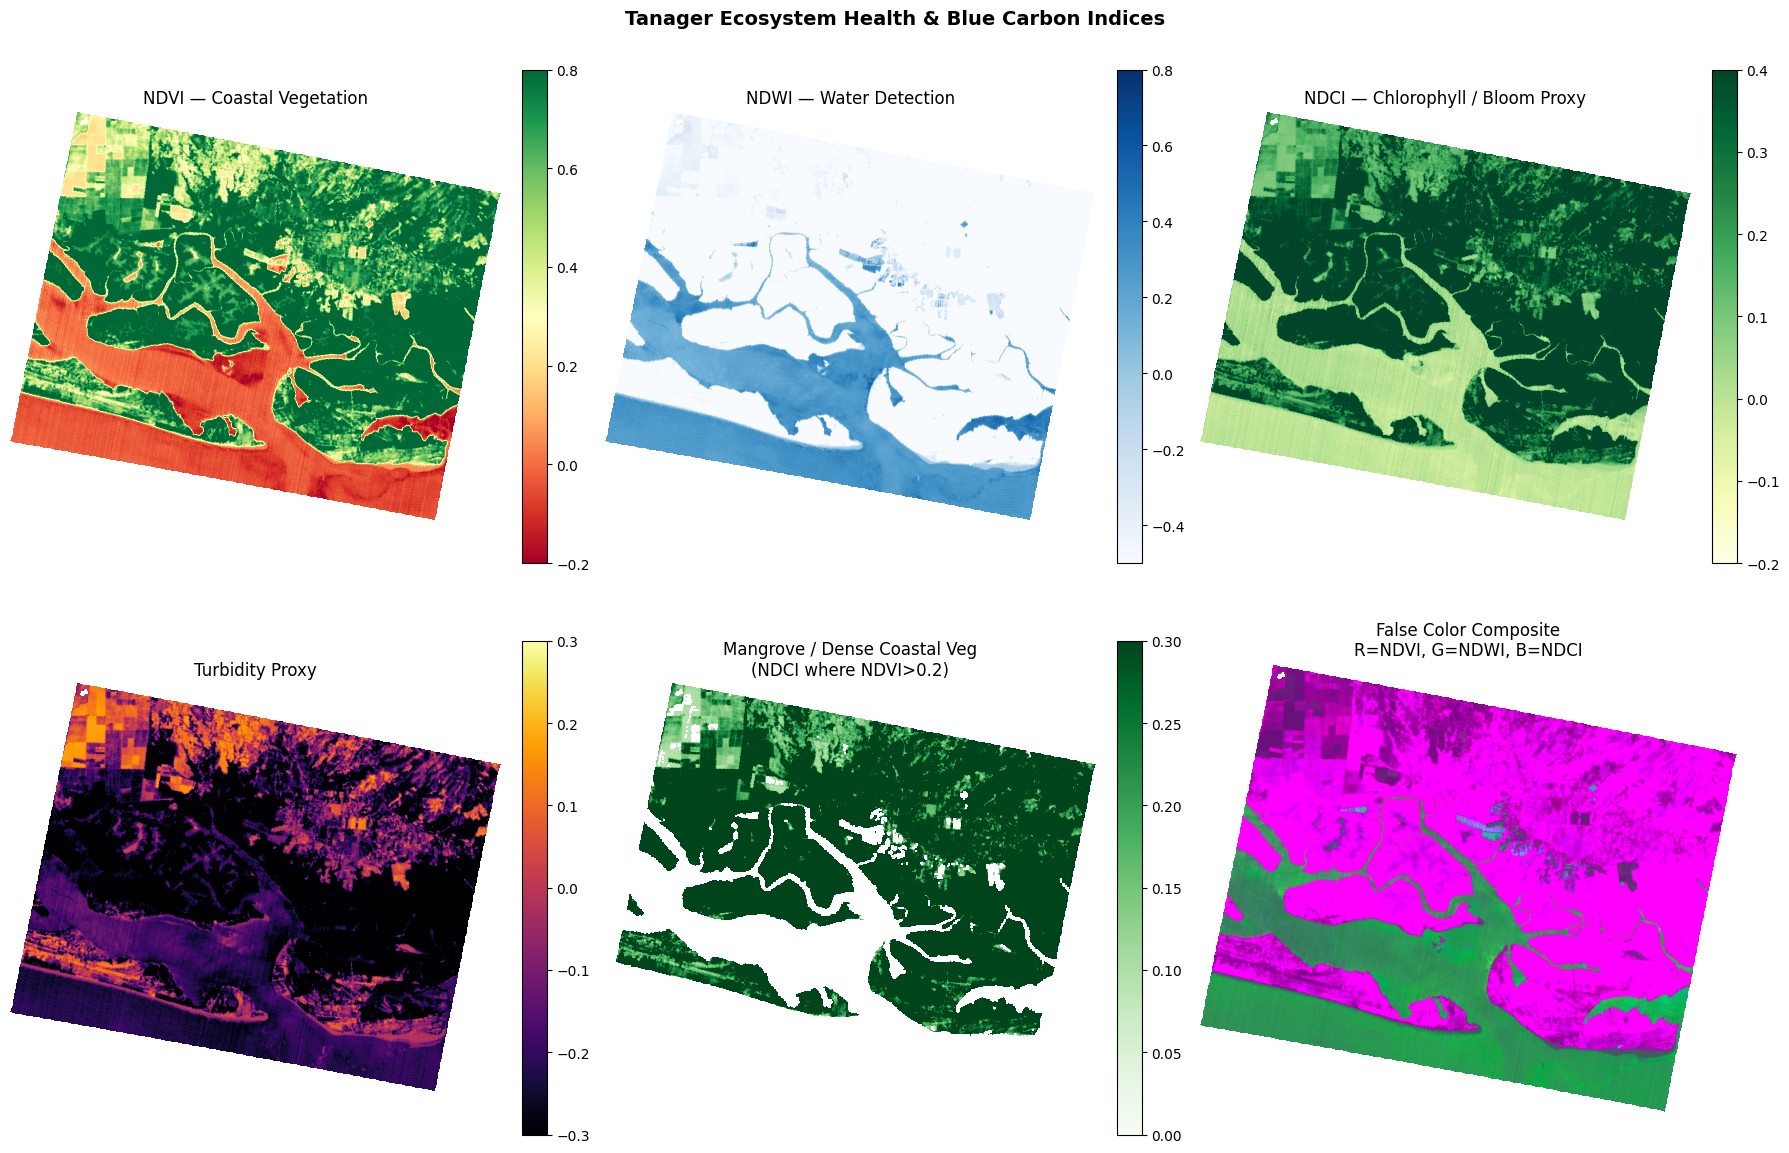

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

im1 = axes[0,0].imshow(NDVI, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[0,0].set_title("NDVI — Coastal Vegetation"); axes[0,0].axis("off")
plt.colorbar(im1, ax=axes[0,0], fraction=0.046, pad=0.04)

im2 = axes[0,1].imshow(NDWI, cmap="Blues", vmin=-0.5, vmax=0.8)
axes[0,1].set_title("NDWI — Water Detection"); axes[0,1].axis("off")
plt.colorbar(im2, ax=axes[0,1], fraction=0.046, pad=0.04)

im3 = axes[0,2].imshow(NDCI, cmap="YlGn", vmin=-0.2, vmax=0.4)
axes[0,2].set_title("NDCI — Chlorophyll / Bloom Proxy"); axes[0,2].axis("off")
plt.colorbar(im3, ax=axes[0,2], fraction=0.046, pad=0.04)

im4 = axes[1,0].imshow(Turbidity, cmap="inferno", vmin=-0.3, vmax=0.3)
axes[1,0].set_title("Turbidity Proxy"); axes[1,0].axis("off")
plt.colorbar(im4, ax=axes[1,0], fraction=0.046, pad=0.04)

im5 = axes[1,1].imshow(Mangrove_proxy, cmap="Greens", vmin=0, vmax=0.3)
axes[1,1].set_title("Mangrove / Dense Coastal Veg\n(NDCI where NDVI>0.2)"); axes[1,1].axis("off")
plt.colorbar(im5, ax=axes[1,1], fraction=0.046, pad=0.04)

# False-color composite: R=NDVI, G=NDWI, B=NDCI
rgb = np.stack([
    np.clip((NDVI + 0.2) / 1.0, 0, 1),
    np.clip((NDWI + 0.5) / 1.3, 0, 1),
    np.clip((NDCI + 0.2) / 0.6, 0, 1)
], axis=-1)
axes[1,2].imshow(rgb)
axes[1,2].set_title("False Color Composite\nR=NDVI, G=NDWI, B=NDCI"); axes[1,2].axis("off")

plt.suptitle("Tanager Ecosystem Health & Blue Carbon Indices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

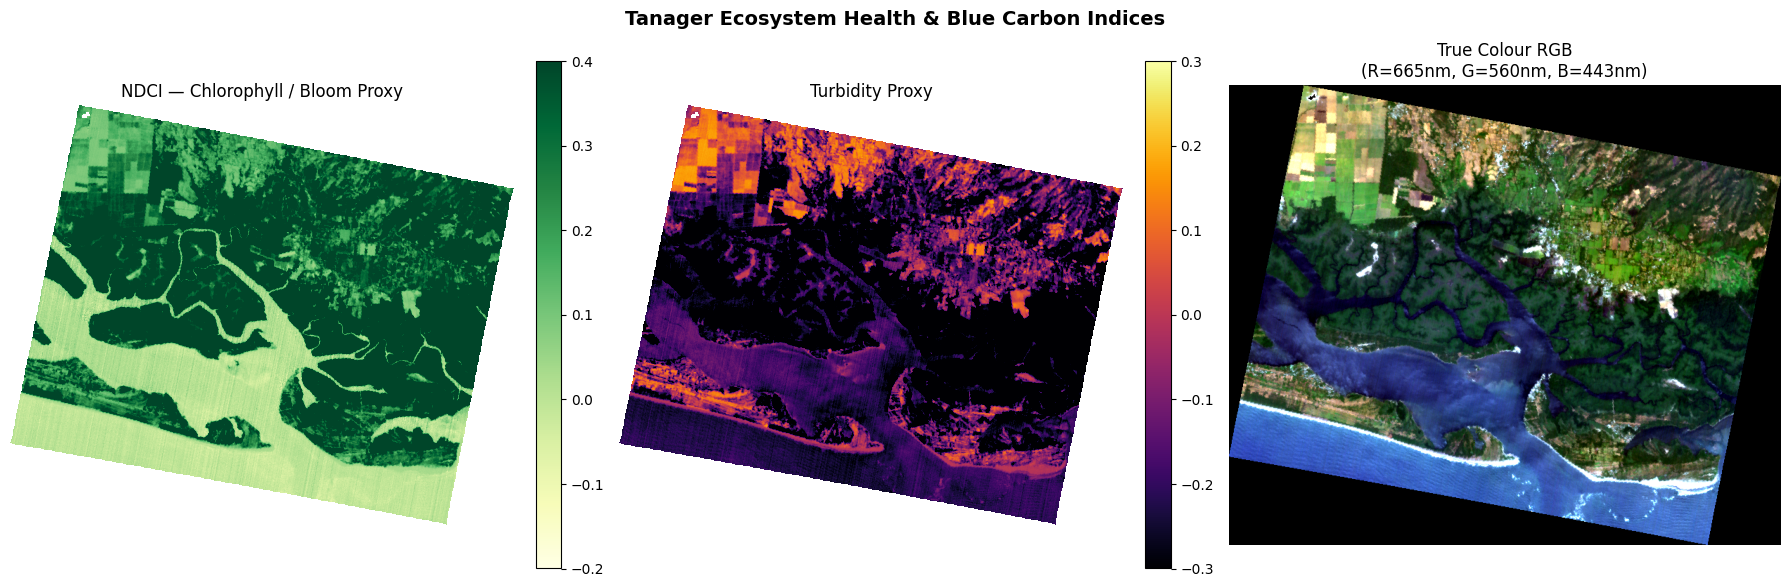

In [49]:
# True RGB composite using Tanager surface reflectance bands
# R = 665 nm, G = 560 nm, B = 443 nm
# Percentile stretch so the image isn't washed out or too dark
def stretch(arr, p_low=2, p_high=98):
    lo, hi = np.nanpercentile(arr, p_low), np.nanpercentile(arr, p_high)
    return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)

rgb_true = np.stack([
    stretch(R_665),   # Red channel
    stretch(R_560),   # Green channel
    stretch(R_443),   # Blue channel
], axis=-1)
# Replace NaN pixels with 0 for display
rgb_true = np.nan_to_num(rgb_true, nan=0.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # was (18,12) — too tall for 1 row

im1 = axes[0].imshow(NDCI, cmap="YlGn", vmin=-0.2, vmax=0.4)
axes[0].set_title("NDCI — Chlorophyll / Bloom Proxy"); axes[0].axis("off")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)  # was im3 (wrong variable)

im2 = axes[1].imshow(Turbidity, cmap="inferno", vmin=-0.3, vmax=0.3)
axes[1].set_title("Turbidity Proxy"); axes[1].axis("off")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)  # was im4 (wrong variable)

axes[2].imshow(rgb_true)
axes[2].set_title("True Colour RGB\n(R=665nm, G=560nm, B=443nm)"); axes[2].axis("off")  # was axes[1,2] (wrong indexing for 1-row grid)

plt.suptitle("Tanager Ecosystem Health & Blue Carbon Indices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 11 – Summary Statistics


In [50]:
def summarize(name, arr):
    valid_data = arr[~np.isnan(arr)]
    if len(valid_data) == 0:
        print(f"{name}: no valid data")
        return
    print(f"{name}: min={valid_data.min():.3f}  max={valid_data.max():.3f}  "
          f"mean={valid_data.mean():.3f}  std={valid_data.std():.3f}")

summarize("NDVI",      NDVI)
summarize("NDWI",      NDWI)
summarize("NDCI",      NDCI)
summarize("Turbidity", Turbidity)

NDVI: min=-0.333  max=0.978  mean=0.496  std=0.369
NDWI: min=-0.847  max=0.632  mean=-0.373  std=0.416
NDCI: min=-0.176  max=0.874  mean=0.304  std=0.236
Turbidity: min=-0.846  max=0.223  mean=-0.230  std=0.164


## Step 12 – Mean Spectrum (Full Scene)

The spectral signature integrates all land cover types in the scene.
Look for the chlorophyll absorption dip at ~680 nm and the vegetation red-edge jump at ~720 nm.


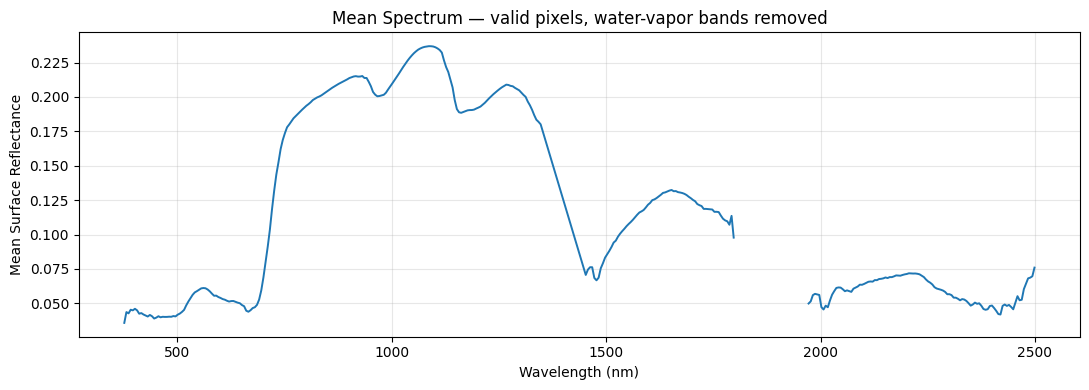

In [51]:
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

stride = 8
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
    cube = sr[good_idx, ::stride, ::stride].astype("float32")
    mask = valid[::stride, ::stride]
    cube[:, ~mask] = np.nan
    cube[cube < 0] = np.nan
    mean_spec = np.nanmean(cube, axis=(1,2))

import matplotlib.pyplot as plt
wls = [wavelengths_nm[i] for i in good_idx]
plt.figure(figsize=(11,4))
plt.plot(wls, mean_spec, lw=1.4)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Mean Spectrum — valid pixels, water-vapor bands removed")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 13 – Water vs Vegetation Spectral Comparison

Compare the average spectrum of water pixels (NDWI > 0.1) vs vegetation pixels (NDVI > 0.3).


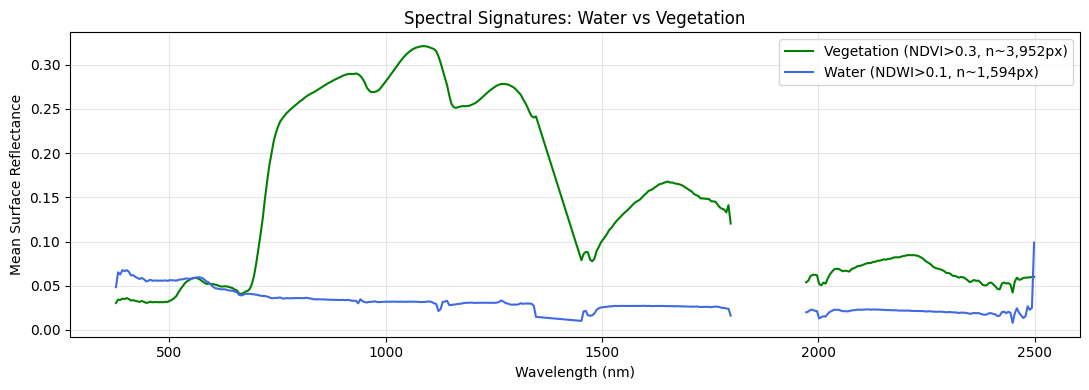

In [52]:
import h5py, matplotlib.pyplot as plt

stride = 8
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
wls = [wavelengths_nm[i] for i in good_idx]

water_mask = (NDWI > 0.1) & valid
veg_mask   = (NDVI > 0.3) & valid

def mean_spec(mask):
    with h5py.File(local_path, "r") as f:
        sr = f[f"{root}/surface_reflectance"]
        cube = sr[good_idx, ::stride, ::stride].astype("float32")
    m = mask[::stride, ::stride]
    cube[:, ~m] = np.nan
    cube[cube < 0] = np.nan
    return [float(np.nanmean(cube[j])) for j in range(len(good_idx))]

spec_water = mean_spec(water_mask)
spec_veg   = mean_spec(veg_mask)

plt.figure(figsize=(11, 4))
plt.plot(wls, spec_veg,   color="green",  lw=1.5, label=f"Vegetation (NDVI>0.3, n~{veg_mask.sum()//stride**2:,}px)")
plt.plot(wls, spec_water, color="royalblue", lw=1.5, label=f"Water (NDWI>0.1, n~{water_mask.sum()//stride**2:,}px)")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Spectral Signatures: Water vs Vegetation")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 🚀 Hackathon Challenge Ideas

- **Mangrove area estimation** — threshold the Mangrove_proxy map and compute area in km²
- **Algal bloom detection** — find pixels where NDCI > 0.2 within NDWI-positive water bodies
- **Seagrass mapping** — shallow water with positive NDVI signature
- **Carbon stock estimation** — combine mangrove extent with published carbon density values (t C/ha)
- **Turbidity monitoring** — track sediment plumes from rivers or coastal construction

> 📖 Created by: [LInkedin: Dr. Vincent Markiet - Space42](https://www.linkedin.com/in/vincentmarkiet/) 

> 📖 Data license: CC-BY-4.0 © Planet Labs PBC
